# 알고리즘 기말 프로젝트 - Score Function Design

- **제출일**: `2026.05.21`
- **파일명**: `final_v1.ipynb`

## 학번 / 이름

- **학번**: `20250786`
- **이름**: `김나연`
- **score에 대한 간략한 설명**: PubChem `Agrochemical` 데이터를 positive로 두고, 분자 물성 범위, Murcko scaffold 기반 SMARTS 패턴, Morgan fingerprint Tanimoto 유사도를 결합해 `pesticide`-likeness를 계산하는 score이다. 같은 코드에서 파일 이름만 바꾸면 HumanDrugs 같은 다른 화학 제품군에도 적용되도록 작성했다.


## 채점 기준 (100점)

| 영역 | 배점 | 만점 기준 |
|---|---|---|
| **(1) Negative 데이터 준비** | 20 | "구조 유사도"를 통해 negative 집합을 찾아낸 기준? (유사도 측정 방법 & Structural similarity 기준 설정) |
| **(2) Score 함수 설계** | 20 | **(a) 분자 속성 범위 (전체 데이터에서 property 범위 계산 방식)** + **(b) alert 구조 패턴(scaffold 및 부분 구조의 smarts 패턴)** 두 요소 모두 포함. score에 대한 설명은 markdown에 기재. |
| **(3) Score 평가 — goodness** | 20 | positive vs negative 점수 분포 비교 (히스토그램/ROC/AUC 등 score 성능의 근거가 되는 시각화 자료 제시) |
| **(4) 설명** | 10 | 각 알고리즘을 mermaid를 이용해서 표현하고 설명글 추가 (markdown 및 주석으로 표기) |


### 가산점 (선택)

| 가산 | 점수 | 조건 |
|---|---|---|
| **(A) 다른 화학 제품군 score** | +10 | pesticide 외 1종 이상(cosmetic / food additive / fragrance / surfactant / dye 등)의 PubChem classification 데이터로 별도 score 함수 설계 + 평가 |
| **(B) Score 기반 구조 생성** | +10 | 본인 score 를 reward 로 사용해 score가 개선된 새로운 구조 생성. |
| **(C) 계산 자원과 계산 시간** | +10 | mpi를 이용해서 대량의 자원으로 계산 시간을 대폭 줄이거나, local 환경에서 합리적으로 계산이 진행될 수 있도록 문제를 효율적으로 압축시킨 방법 적용 (mpi script와 계산 결과에 대한 log 필요) |

### 제출 결과물 (결과를 재현하기 위해 필요한 파일들)
1. ipynb (mpi를 사용했다면, mpi4py script)
2. data files (pesticide, cosmetics, food additives, drug, ..., format: csv)
3. negative list file (format: csv)
4. score 평가 시각화 자료 (mpi에서 실행해서 얻은 plot은 notebook markdown에 삽입)

In [1]:
# 공통 import 모음
# 아래 라이브러리들은 뒤쪽 모든 Task에서 함께 사용하므로 맨 위에 한 번만 불러온다.

# 파일 경로 처리, 시간 측정, 빈도 계산에 필요한 기본 파이썬 도구
import math
import time
from pathlib import Path
from collections import Counter

cell_start = time.perf_counter()
NOTEBOOK_START = cell_start
CELL_TIMES = []

# 표 형태 데이터 처리와 숫자 계산
import numpy as np
import pandas as pd

# 그래프와 분자 구조 그림 표시
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# RDKit: SMILES를 분자로 바꾸고, descriptor/fingerprint/SMARTS/scaffold를 계산
from rdkit import Chem, DataStructs, RDLogger
from rdkit.Chem import Descriptors, Crippen, Draw, rdFingerprintGenerator
from rdkit.Chem.Scaffolds import MurckoScaffold

# score 성능 평가: ROC/PR curve, AUC, confusion matrix, accuracy/precision/recall/F1 계산
from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    matthews_corrcoef,
)

# RDKit 경고가 너무 많이 나오면 노트북 출력이 지저분해져서 숨긴다.
RDLogger.DisableLog('rdApp.*')

def show_runtime(label, cell_start):
    # 셀 하나가 걸린 시간과 노트북 시작 후 누적 시간을 함께 보여준다.
    cell_seconds = time.perf_counter() - cell_start
    total_seconds = time.perf_counter() - NOTEBOOK_START
    CELL_TIMES.append({
        'step': label,
        'cell_seconds': cell_seconds,
        'cumulative_seconds': total_seconds,
    })
    print(f"[시간] {label}: 셀 {cell_seconds:.2f}초 / 누적 {total_seconds:.2f}초")

show_runtime('공통 import', cell_start)


[시간] 공통 import: 셀 1.19초 / 누적 1.19초


---
# Task 1. Negative 데이터 준비 (25점)

**문제**: 양성(positive) 분자와 "구조적으로 다른" 분자 집합을 어떻게 만들 것인가?

Score 함수의 평가는 **양성과 음성을 얼마나 잘 구분하는가** 로 측정합니다. 그러려면 먼저 음성 집합을 정의해야 합니다.



**본인 선택과 이유**

- 선택한 기준: Positive는 `PubChem_Agrochemical.csv`, negative 후보는 `zinc_db` 폴더의 ZINC 구조 파일로 둔다. 이 폴더의 첫 번째 파일(`AAAA.txt`)을 확인해 보니 tab-separated 형식이고 `smiles`, `zinc_id`, `mwt`, `logp` 등의 컬럼이 있었다. 따라서 코드는 `zinc_db/*.txt` 파일을 같은 형식으로 읽도록 작성했다.
- 구조 차이 기준: Morgan fingerprint(radius=2, 2048 bits)와 Tanimoto 유사도를 사용하고, positive 학습 집합과의 최대 유사도(`max_similarity_to_positive`)가 `0.30 이하`인 ZINC 분자만 negative로 선택한다.
- 이유: Tanimoto 값이 작을수록 fingerprint에서 공유하는 구조 특징이 적다. 단순히 "0.8이면 비슷하다고 알려져 있다"라고 쓰는 대신, 아래 코드에서 0.0~1.0을 0.1 단위로 나누어 실제 구조 예시를 여러 개씩 시각화해 기준을 눈으로 확인한다.



**수업자료에서 추가한 내용 - Task 1 위치**

- `w11-2_fingerprint_tanimoto.ipynb`: Morgan fingerprint, Tanimoto 공식, `BulkTanimotoSimilarity`, 농약 DB와의 최대 유사도 함수 흐름을 사용했다.
- `w2-2_download_zinc.ipynb`, `W1-2AL.ipynb`: ZINC txt 파일이 tab-separated 구조이고 `smiles` 컬럼을 중심으로 읽을 수 있다는 점을 반영했다.
- `w6-2_search_algorithm.ipynb`: 대량 SMILES 탐색은 자료구조 선택이 속도를 좌우한다는 내용을 반영했다.
- `mpi_compare_search.py` 및 `search_results*.txt`: 대량 ZINC 탐색에서 MPI와 hash search를 사용해 검색 시간을 줄인 기록이 있어, 가산 C 설명에서 함께 인용한다.


In [2]:
# Task 1-1. 설정값 정리
cell_start = time.perf_counter()
# 여기 있는 값만 바꾸면 다른 파일이나 더 많은 ZINC 파일로 다시 실행할 수 있다.

CONFIG = {
    # 현재 노트북이 있는 폴더를 기준으로 파일을 찾는다.
    'base_dir': Path('.'),

    # positive 데이터: 농약으로 분류된 PubChem CSV
    'positive_file': 'PubChem_Agrochemical.csv',

    # negative 후보 데이터: ZINC txt 파일들이 들어 있는 폴더
    'zinc_dir': 'zinc_db',

    # 기본값은 첫 번째 ZINC 파일만 읽는다.
    # 전체 zinc_db를 쓰고 싶으면 None으로 바꾼다.
    'zinc_file_limit': 1,

    # 파일 안에서 읽을 행 수 제한. None이면 선택된 파일 전체를 읽는다.
    'zinc_rows_per_file': None,

    # 가산 A에서 사용할 다른 제품군 파일
    'alt_positive_file': 'PubChem_HumanDrugs.csv',

    # 랜덤 샘플링을 재현 가능하게 만드는 숫자
    'random_state': 42,

    # positive를 기준용(train)과 평가용(test)으로 나누는 개수
    'train_positive_n': 1200,
    'test_positive_n': 800,

    # 최종 negative로 뽑을 개수
    'negative_n': 800,

    # positive와 충분히 다르다고 볼 Tanimoto 최대 유사도 기준
    'negative_similarity_threshold': 0.30,

    # Morgan fingerprint 설정
    'fingerprint_radius': 2,
    'fingerprint_bits': 2048,

    # 생성할 negative 파일 이름
    'output_negative_file': 'negative_agro_vs_zinc.csv',

    # score 최적화 실험 설정
    # quantiles는 물성 범위이다. (0.05, 0.95)는 5~95%, (0.10, 0.90)은 10~90%를 뜻한다.
    # weights는 최종 score에서 property/smarts/similarity를 얼마나 반영할지 정한다.
    'score_experiments': [
        {'name': 'q05_95_w30_25_45', 'quantiles': (0.05, 0.95), 'weights': {'property': 0.30, 'smarts': 0.25, 'similarity': 0.45}},
        {'name': 'q10_90_w30_25_45', 'quantiles': (0.10, 0.90), 'weights': {'property': 0.30, 'smarts': 0.25, 'similarity': 0.45}},
        {'name': 'q05_95_w40_20_40', 'quantiles': (0.05, 0.95), 'weights': {'property': 0.40, 'smarts': 0.20, 'similarity': 0.40}},
        {'name': 'q10_90_w40_20_40', 'quantiles': (0.10, 0.90), 'weights': {'property': 0.40, 'smarts': 0.20, 'similarity': 0.40}},
        {'name': 'q05_95_w25_25_50', 'quantiles': (0.05, 0.95), 'weights': {'property': 0.25, 'smarts': 0.25, 'similarity': 0.50}},
        {'name': 'q10_90_w25_25_50', 'quantiles': (0.10, 0.90), 'weights': {'property': 0.25, 'smarts': 0.25, 'similarity': 0.50}},
        {'name': 'q05_95_w50_20_30', 'quantiles': (0.05, 0.95), 'weights': {'property': 0.50, 'smarts': 0.20, 'similarity': 0.30}},
        {'name': 'q10_90_w50_20_30', 'quantiles': (0.10, 0.90), 'weights': {'property': 0.50, 'smarts': 0.20, 'similarity': 0.30}},
    ],
}

# PubChem CSV와 ZINC txt는 컬럼 이름이 조금 다르다.
# 뒤 코드에서 같은 이름으로 쓰기 위해 표준 이름으로 바꾼다.
COLUMN_ALIASES = {
    'Compound_CID': 'cid',
    'Name': 'cmpdname',
    'SMILES': 'smiles',
    'Molecular_Weight': 'mw',
    'mwt': 'mw',
    'XLogP': 'xlogp',
    'logp': 'xlogp',
    'H-Bond_Acceptor_Count': 'hbondacc',
    'H-Bond_Donor_Count': 'hbonddonor',
    'Polar_Area': 'polararea',
    'Rotatable_Bond_Count': 'rotbonds',
}

show_runtime('Task 1-1. 설정값 정리', cell_start)

[시간] Task 1-1. 설정값 정리: 셀 0.00초 / 누적 1.20초


In [3]:
# Task 1-2. 파일 읽기와 Tanimoto 계산 함수
cell_start = time.perf_counter()
# 함수로 빼두면 같은 동작을 여러 Task에서 다시 사용할 수 있다.

def load_pubchem_csv(filename, base_dir=CONFIG['base_dir']):
    # PubChem CSV를 읽고, SMILES를 RDKit Mol 객체로 바꾼다.
    path = Path(base_dir) / filename
    df = pd.read_csv(path)

    # 컬럼 이름을 표준 이름으로 바꾼다.
    df = df.rename(columns={k: v for k, v in COLUMN_ALIASES.items() if k in df.columns})

    # smiles 컬럼이 없으면 이 뒤 계산을 할 수 없으므로 바로 에러를 낸다.
    if 'smiles' not in df.columns:
        raise ValueError(f'{filename}에 smiles/SMILES 컬럼이 없습니다.')

    # smiles가 비어 있는 행과 중복 smiles를 제거한다.
    df = df.dropna(subset=['smiles']).drop_duplicates('smiles').copy()

    # SMILES 문자열을 RDKit 분자 객체로 바꾼다.
    # 잘못된 SMILES는 None이 나오므로 제거한다.
    df['mol'] = df['smiles'].map(lambda s: Chem.MolFromSmiles(str(s)))
    df = df[df['mol'].notna()].reset_index(drop=True)
    return df


def load_zinc_candidates(zinc_dir, base_dir=CONFIG['base_dir'], file_limit=1, rows_per_file=None):
    # zinc_db/*.txt 파일을 읽어서 negative 후보 DataFrame을 만든다.
    zinc_path = Path(base_dir) / zinc_dir
    zinc_files = sorted(zinc_path.glob('*.txt'))

    # file_limit이 1이면 첫 번째 파일만, None이면 전체 파일을 사용한다.
    if file_limit is not None:
        zinc_files = zinc_files[:file_limit]

    frames = []
    for file_path in zinc_files:
        # 첫 번째 파일을 확인한 결과 tab으로 구분된 txt였다.
        # usecols로 필요한 컬럼만 읽으면 더 빠르고 메모리도 덜 쓴다.
        df = pd.read_csv(
            file_path,
            sep='\t',
            usecols=['smiles', 'zinc_id', 'mwt', 'logp'],
            nrows=rows_per_file,
        )
        df['source_file'] = file_path.name
        frames.append(df)

    if not frames:
        raise ValueError('읽을 ZINC txt 파일이 없습니다.')

    zinc_df = pd.concat(frames, ignore_index=True)
    zinc_df = zinc_df.rename(columns={k: v for k, v in COLUMN_ALIASES.items() if k in zinc_df.columns})
    zinc_df = zinc_df.dropna(subset=['smiles']).drop_duplicates('smiles').copy()
    zinc_df['mol'] = zinc_df['smiles'].map(lambda s: Chem.MolFromSmiles(str(s)))
    zinc_df = zinc_df[zinc_df['mol'].notna()].reset_index(drop=True)
    return zinc_df


# Morgan fingerprint 생성기를 한 번 만들어 두고 계속 재사용한다.
FP_GENERATOR = rdFingerprintGenerator.GetMorganGenerator(
    radius=CONFIG['fingerprint_radius'],
    fpSize=CONFIG['fingerprint_bits'],
)


def make_fingerprint(mol):
    # RDKit Mol 하나를 Morgan fingerprint로 바꾼다.
    return FP_GENERATOR.GetFingerprint(mol)


def max_tanimoto_to_refs(mol, ref_fps):
    # 분자 하나가 기준 fingerprint 목록 중 가장 비슷한 것과 얼마나 비슷한지 계산한다.
    fp = make_fingerprint(mol)
    sims = DataStructs.BulkTanimotoSimilarity(fp, ref_fps)
    return max(sims) if sims else 0.0


def max_tanimoto_with_match(mol, ref_fps, ref_smiles):
    # 최대 Tanimoto 값과 그때 매칭된 positive SMILES를 같이 돌려준다.
    fp = make_fingerprint(mol)
    sims = DataStructs.BulkTanimotoSimilarity(fp, ref_fps)

    if not sims:
        return 0.0, None

    best_idx = int(np.argmax(sims))
    return float(sims[best_idx]), ref_smiles[best_idx]

show_runtime('Task 1-2. 파일 읽기와 Tanimoto 계산 함수', cell_start)

[시간] Task 1-2. 파일 읽기와 Tanimoto 계산 함수: 셀 0.00초 / 누적 1.21초


In [4]:
# Task 1-3. positive와 ZINC 후보 데이터 읽기
cell_start = time.perf_counter()

# 1. positive 농약 데이터 로드
positive_df = load_pubchem_csv(CONFIG['positive_file'])

# 2. negative 후보 ZINC 데이터 로드
negative_candidate_df = load_zinc_candidates(
    CONFIG['zinc_dir'],
    file_limit=CONFIG['zinc_file_limit'],
    rows_per_file=CONFIG['zinc_rows_per_file'],
)

# 3. positive를 train/test로 분리
# train_positive: negative를 고를 때 기준으로 쓰는 positive
# test_positive : score 평가 때 쓰는 positive
train_positive = positive_df.sample(
    min(CONFIG['train_positive_n'], len(positive_df)),
    random_state=CONFIG['random_state'],
)
remaining_positive = positive_df.drop(train_positive.index)
test_positive = remaining_positive.sample(
    min(CONFIG['test_positive_n'], len(remaining_positive)),
    random_state=CONFIG['random_state'] + 1,
)

# 4. train positive의 fingerprint 목록을 만든다.
positive_ref_fps = [make_fingerprint(mol) for mol in train_positive['mol']]
positive_ref_smiles = train_positive['smiles'].tolist()

print('positive_total:', len(positive_df))
print('positive_train:', len(train_positive))
print('positive_test:', len(test_positive))
print('zinc_candidate_total:', len(negative_candidate_df))
print('zinc_files_used:', CONFIG['zinc_file_limit'])

show_runtime('Task 1-3. positive와 ZINC 후보 데이터 읽기', cell_start)

positive_total: 3085
positive_train: 1200
positive_test: 800
zinc_candidate_total: 3729
zinc_files_used: 1
[시간] Task 1-3. positive와 ZINC 후보 데이터 읽기: 셀 0.54초 / 누적 1.75초


In [5]:
# Task 1-4. ZINC 후보 중 negative 선택
cell_start = time.perf_counter()

negative_rows = []

# for문: ZINC 후보를 한 개씩 꺼내서 검사한다.
for _, row in negative_candidate_df.sample(frac=1, random_state=CONFIG['random_state'] + 2).iterrows():
    # 현재 ZINC 후보가 positive train 집합 중 누구와 가장 비슷한지 계산한다.
    max_sim, matched_positive = max_tanimoto_with_match(
        row['mol'],
        positive_ref_fps,
        positive_ref_smiles,
    )

    # if문: 최대 유사도도 0.30 이하이면 positive와 충분히 다르다고 보고 negative로 저장한다.
    if max_sim <= CONFIG['negative_similarity_threshold']:
        item = row.drop(labels=['mol']).to_dict()
        item['max_similarity_to_positive'] = max_sim
        item['matched_positive_smiles'] = matched_positive
        negative_rows.append(item)

    # 필요한 개수만큼 모이면 더 볼 필요가 없으므로 반복을 멈춘다.
    if len(negative_rows) >= CONFIG['negative_n']:
        break

negative_df = pd.DataFrame(negative_rows)
negative_df.to_csv(CONFIG['output_negative_file'], index=False)

print('negative_selected:', len(negative_df))
print('negative_mean_max_similarity:', round(negative_df['max_similarity_to_positive'].mean(), 3))
print('negative_max_similarity:', round(negative_df['max_similarity_to_positive'].max(), 3))
print('negative_file:', CONFIG['output_negative_file'])

show_runtime('Task 1-4. ZINC 후보 중 negative 선택', cell_start)

negative_selected: 800
negative_mean_max_similarity: 0.234
negative_max_similarity: 0.3
negative_file: negative_agro_vs_zinc.csv
[시간] Task 1-4. ZINC 후보 중 negative 선택: 셀 0.40초 / 누적 2.16초


### Tanimoto 0.0-0.1 예시 (6개 후보)

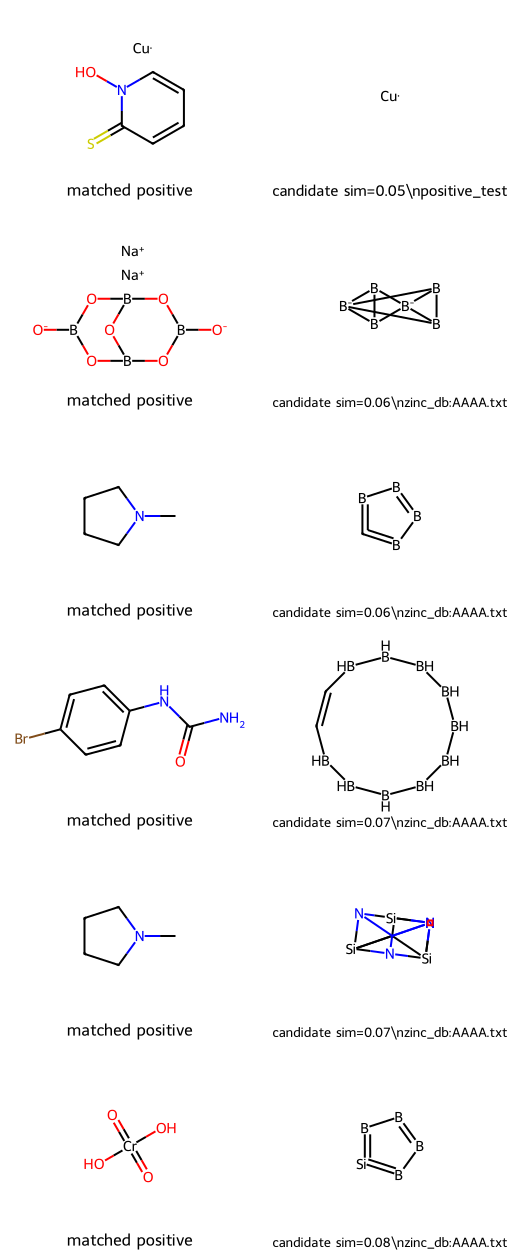

### Tanimoto 0.1-0.2 예시 (6개 후보)

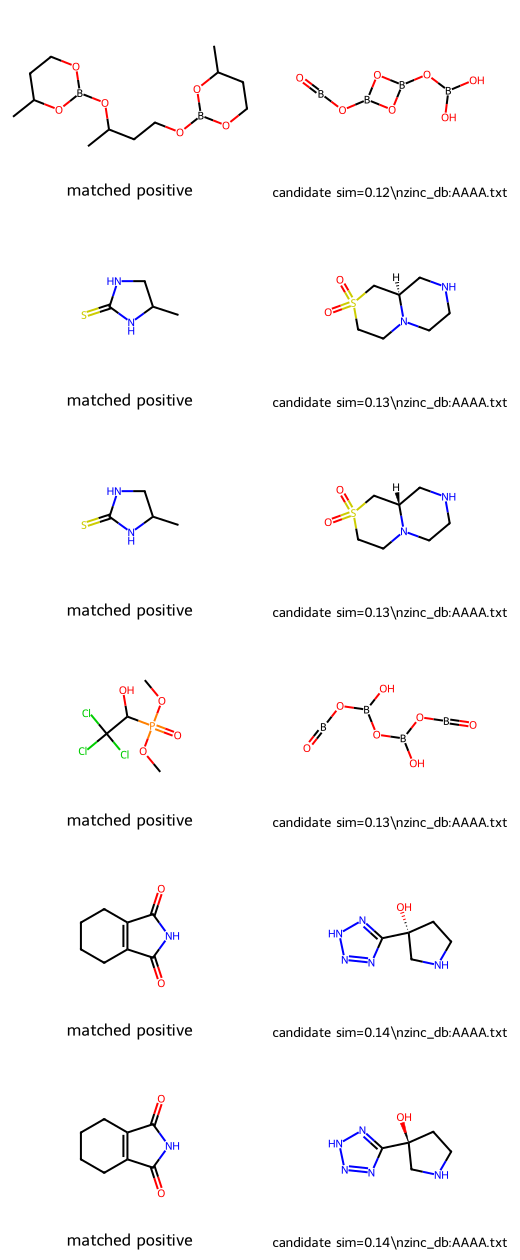

### Tanimoto 0.2-0.3 예시 (6개 후보)

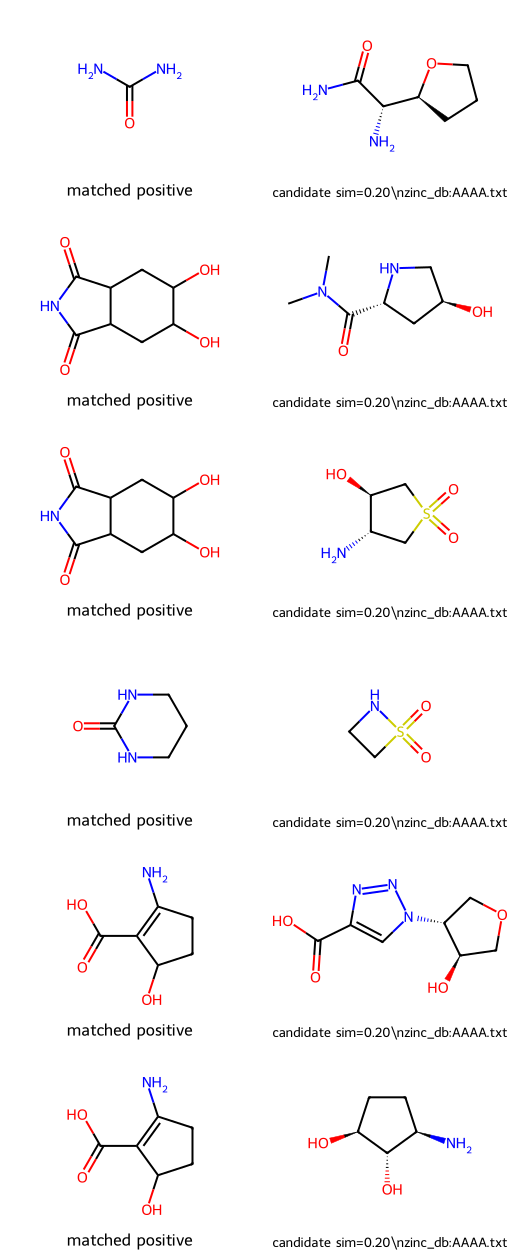

### Tanimoto 0.3-0.4 예시 (6개 후보)

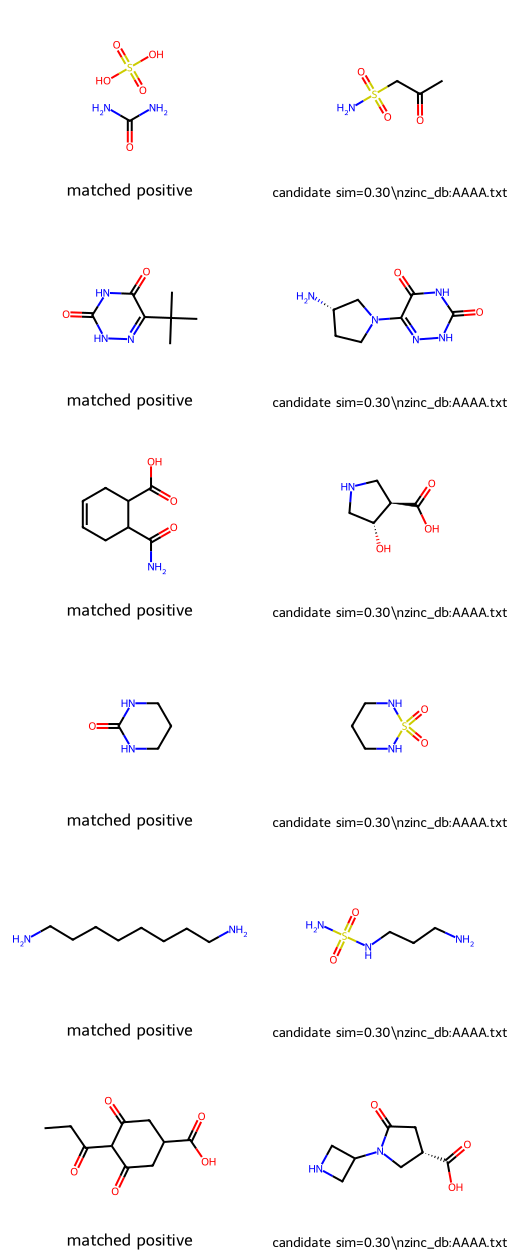

### Tanimoto 0.4-0.5 예시 (6개 후보)

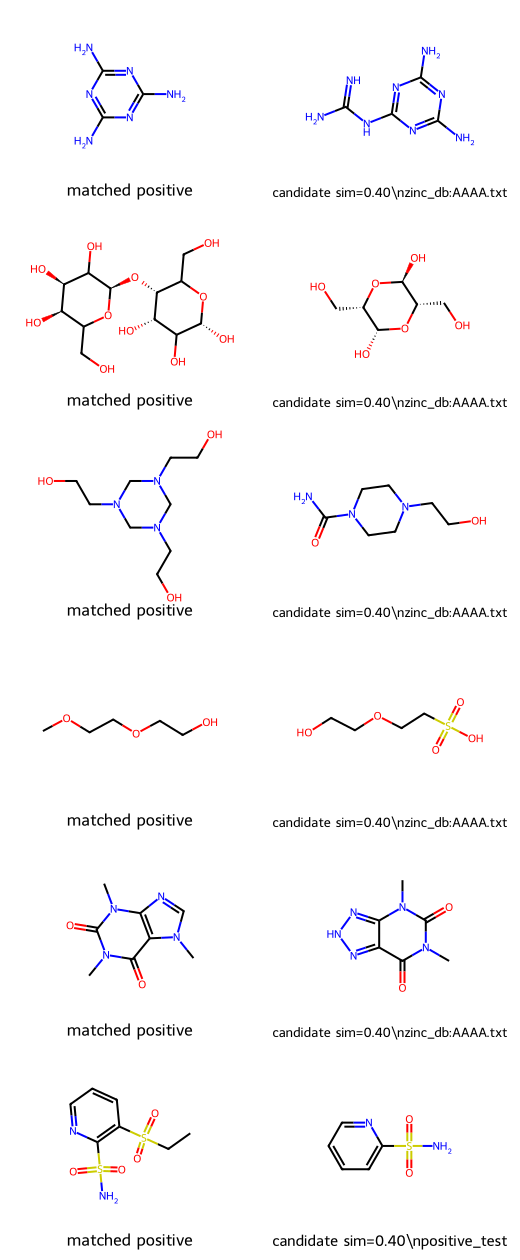

### Tanimoto 0.5-0.6 예시 (6개 후보)

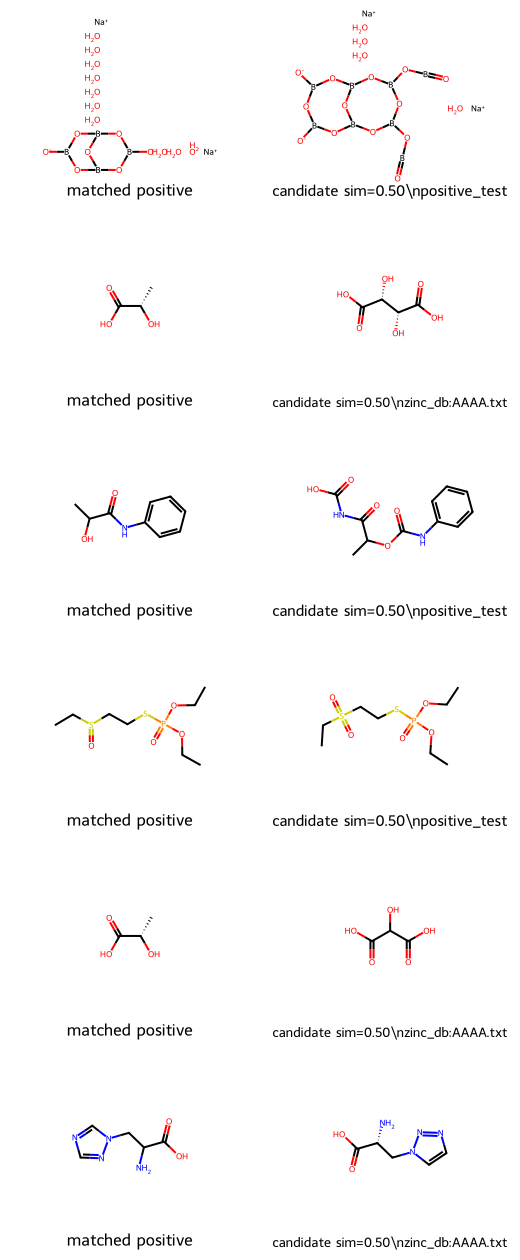

### Tanimoto 0.6-0.7 예시 (6개 후보)

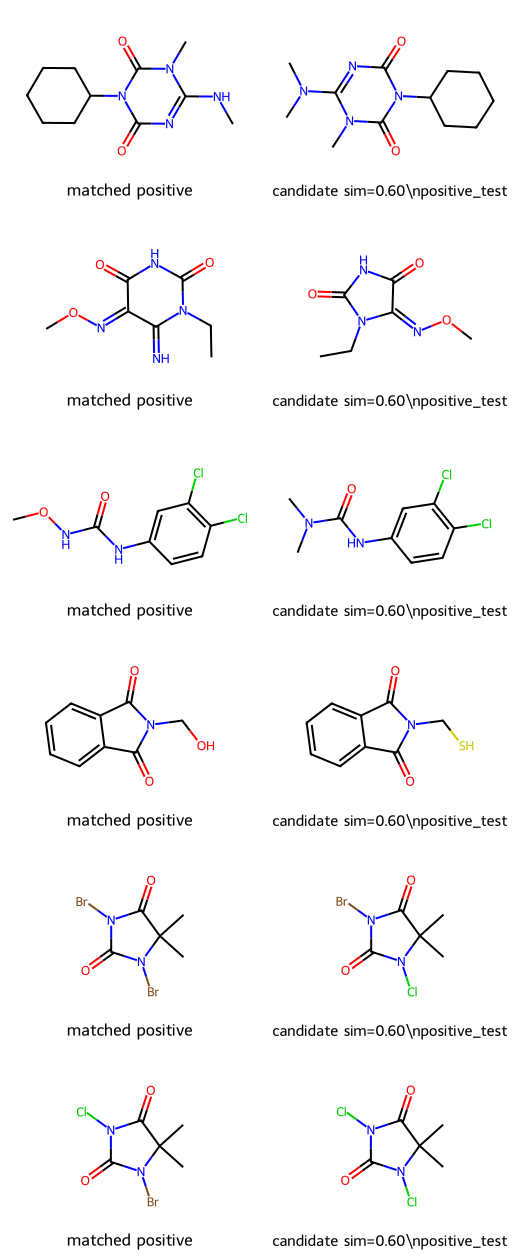

### Tanimoto 0.7-0.8 예시 (6개 후보)

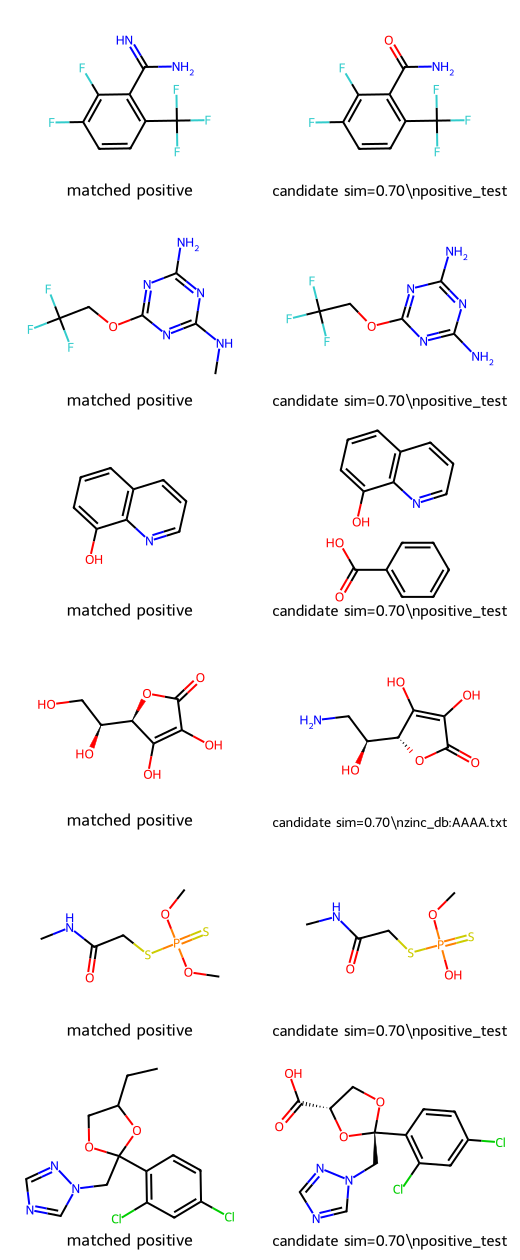

### Tanimoto 0.8-0.9 예시 (6개 후보)

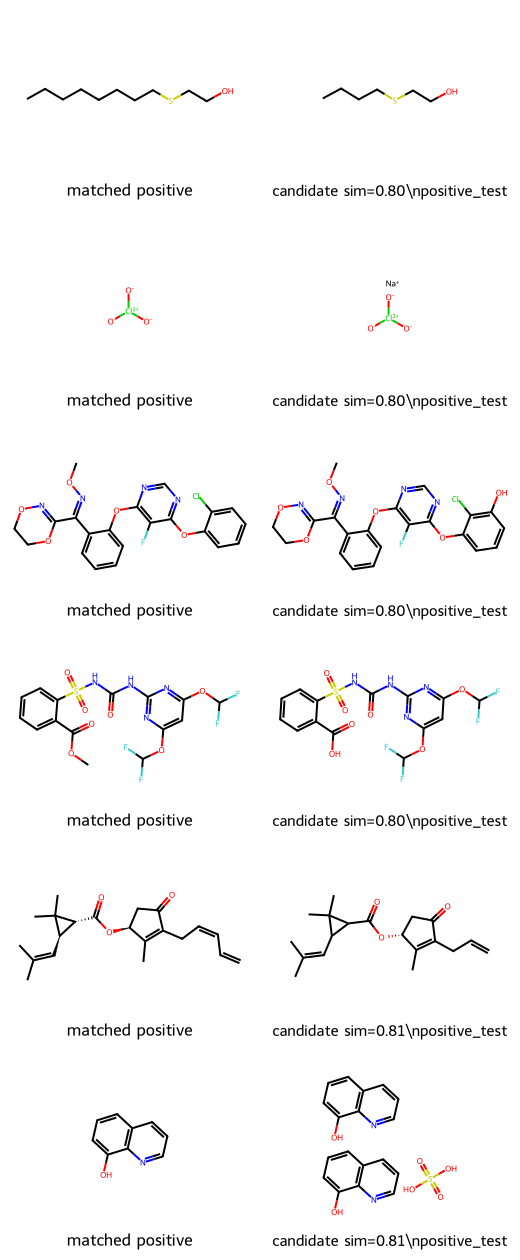

### Tanimoto 0.9-1.0 예시 (6개 후보)

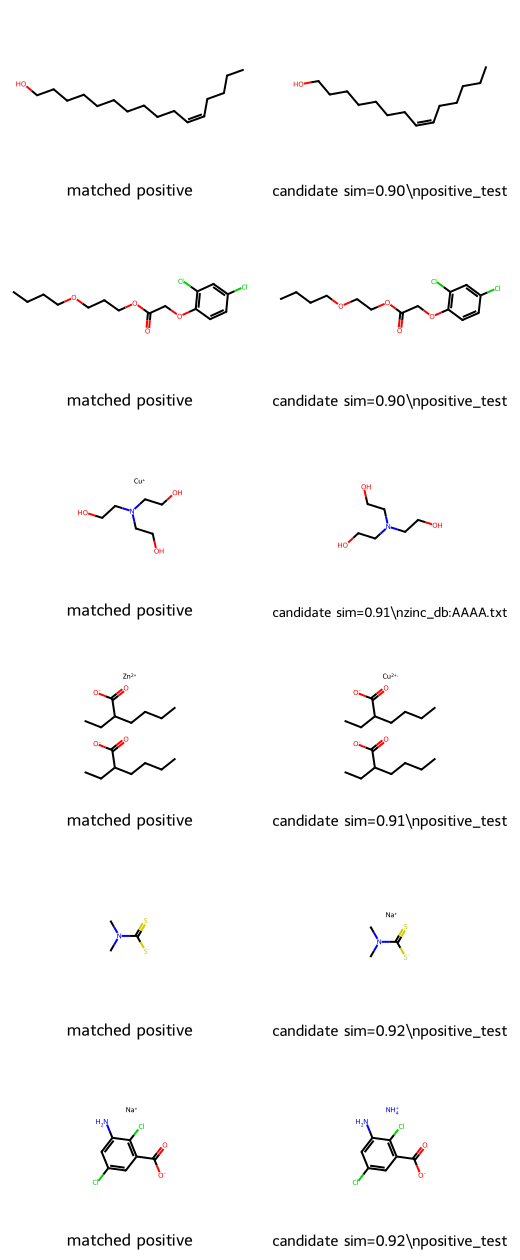

[시간] Task 1-5. Tanimoto 유사도 0.1 단위별 실제 구조 예시 보기: 셀 1.73초 / 누적 3.90초


In [6]:
# Task 1-5. Tanimoto 유사도 0.1 단위별 실제 구조 예시 보기
cell_start = time.perf_counter()

def tanimoto_bin(value):
    # 0.37 같은 값을 '0.3-0.4' 구간 이름으로 바꾼다.
    low = math.floor(float(value) * 10) / 10
    if low >= 1.0:
        low = 0.9
    high = low + 0.1
    return f'{low:.1f}-{high:.1f}'


def build_similarity_examples(examples_per_bin=6):
    # 각 Tanimoto 구간마다 보여줄 예시 구조를 모은다.
    rows = []

    # 낮은 유사도 구간은 ZINC 후보에서 잘 나온다.
    zinc_pool = negative_candidate_df[['smiles', 'mol', 'source_file']].copy()
    zinc_pool['source'] = 'zinc_db:' + zinc_pool['source_file'].astype(str)

    # 높은 유사도 구간은 positive 평가 집합에서 잘 나온다.
    positive_pool = test_positive[['smiles', 'mol']].copy()
    positive_pool['source'] = 'positive_test'

    candidate_pool = pd.concat(
        [
            zinc_pool[['smiles', 'mol', 'source']],
            positive_pool[['smiles', 'mol', 'source']],
        ],
        ignore_index=True,
    )

    for _, row in candidate_pool.iterrows():
        sim, matched_positive = max_tanimoto_with_match(row['mol'], positive_ref_fps, positive_ref_smiles)
        rows.append({
            'candidate_smiles': row['smiles'],
            'candidate_mol': row['mol'],
            'matched_positive_smiles': matched_positive,
            'matched_positive_mol': Chem.MolFromSmiles(matched_positive) if matched_positive else None,
            'similarity': sim,
            'bin': tanimoto_bin(sim),
            'source': row['source'],
        })

    examples = pd.DataFrame(rows)

    # 각 구간에서 examples_per_bin개씩만 선택한다.
    examples = examples.sample(frac=1, random_state=CONFIG['random_state']).reset_index(drop=True)
    selected = (
        examples
        .sort_values(['bin', 'similarity'])
        .groupby('bin', group_keys=False)
        .head(examples_per_bin)
        .reset_index(drop=True)
    )
    return selected


similarity_examples = build_similarity_examples(examples_per_bin=6)

for bin_name in [f'{i/10:.1f}-{(i+1)/10:.1f}' for i in range(10)]:
    part = similarity_examples[similarity_examples['bin'] == bin_name]

    if part.empty:
        display(Markdown(f'### Tanimoto {bin_name}: 예시가 부족해서 표시하지 않음'))
        continue

    display(Markdown(f'### Tanimoto {bin_name} 예시 ({len(part)}개 후보)'))

    mols = []
    legends = []
    for _, row in part.iterrows():
        mols.append(row['matched_positive_mol'])
        legends.append('matched positive')

        mols.append(row['candidate_mol'])
        legends.append(f"candidate sim={row['similarity']:.2f}\\n{row['source']}")

    img = Draw.MolsToGridImage(
        mols,
        molsPerRow=2,
        subImgSize=(260, 210),
        legends=legends,
    )
    display(img)

# 표로도 남겨 두면 나중에 특정 예시의 SMILES를 다시 확인할 수 있다.
similarity_examples[['bin', 'similarity', 'source', 'matched_positive_smiles', 'candidate_smiles']].head(30)

show_runtime('Task 1-5. Tanimoto 유사도 0.1 단위별 실제 구조 예시 보기', cell_start)


**Task 1. 결과 해석**

Negative는 `zinc_db`의 ZINC 구조 중 positive 학습 집합과의 최대 Tanimoto 유사도가 `0.30 이하`인 분자만 남겼다. 위 시각화에서 Tanimoto 구간이 낮을수록 오른쪽 후보 구조가 왼쪽 positive 구조와 공유하는 고리, 치환기, 원자 배열이 적어진다는 것을 직접 확인할 수 있다.

`0.30 이하`를 negative 기준으로 사용한 이유는 score 평가에서 positive와 구조적으로 충분히 다른 집합이 필요하기 때문이다. 반대로 0.7~1.0 구간의 예시는 positive와 비슷한 scaffold나 부분구조를 많이 공유하므로 negative로 쓰기에 부적절하다.



## [상세 설명] Task 1

SMILES 문자열 자체를 문자로 비교하면 분자의 구조적 가까움을 제대로 반영하기 어렵다. 그래서 수업자료에서는 분자를 fingerprint로 바꾸고 Tanimoto 유사도를 계산했다. Morgan fingerprint는 각 원자 주변 반경 안의 결합 환경을 bit vector로 표현한다. 두 분자의 bit vector에서 공통으로 켜진 bit가 많으면 Tanimoto 값이 1에 가까워지고, 공통 구조 특징이 적으면 0에 가까워진다.

이 노트북에서는 positive 전체를 그대로 reference로 쓰지 않고 `train_positive`와 `test_positive`로 나누었다. 이렇게 해야 평가할 positive가 score 함수의 reference에 그대로 들어가서 `max similarity = 1.0`이 되는 누수를 줄일 수 있다.

Negative 후보는 이제 `PubChem_Drugs.csv`가 아니라 `zinc_db`에서 가져온다. 첫 번째 ZINC 파일(`AAAA.txt`)을 확인한 결과 `smiles`, `zinc_id`, `mwt`, `logp` 등이 tab으로 구분되어 있었다. 코드의 `load_zinc_candidates` 함수는 이 형식을 기준으로 ZINC txt 파일을 읽는다. 기본 설정은 실행 시간을 고려해 첫 번째 파일만 읽지만, `CONFIG['zinc_file_limit'] = None`으로 바꾸면 폴더 전체 파일을 읽는 방식으로 확장할 수 있다.

코드의 for문은 ZINC 후보를 하나씩 꺼내고, 그 후보가 positive 기준 구조들과 얼마나 비슷한지 계산한다. if문은 그 최대 유사도가 0.30 이하인지 확인한다. 조건을 만족하면 negative 목록(list)에 추가하고, 필요한 개수만큼 모이면 멈춘다. 즉, 기본 문법으로 보면 `for`는 후보를 반복해서 보는 부분이고, `if`는 negative로 넣을지 말지 결정하는 부분이며, `list`는 선택된 negative를 차곡차곡 모으는 바구니 역할을 한다.


---
# Task 2. Score 함수 설계 (35점)

**문제**: "positive-likeness" 점수를 계산해주는 함수 개발.

Scoring 방식은 세 요소를 결합한다.

1. **분자 속성 범위**: MW, logP, HBA, HBD, TPSA, rotatable bonds의 positive 5%~95% 범위를 계산한다.
2. **SMARTS 패턴**: positive 학습 집합에서 자주 나오는 Murcko scaffold를 뽑고 SMARTS 패턴으로 변환해 부분구조 매칭한다.
3. **구조 유사도 보조항**: Morgan fingerprint의 최대 Tanimoto 유사도를 더해, 같은 물성만 갖지만 구조적으로 먼 분자의 과대평가를 줄인다.

최종 score는 `0.30 * property_score + 0.25 * smarts_score + 0.45 * similarity_score`로 계산한다.


**수업자료에서 추가한 내용 - Task 2 위치**

- `w10-2_agrochemical_score.ipynb`: Tice rule 관점의 MW, logP, HBA, HBD, TPSA 범위 계산과 QED 스타일의 desirability/가중 결합 아이디어를 반영했다.
- `w11-1_smarts_pesticide.ipynb`: Murcko scaffold를 추출하고, scaffold를 SMARTS 패턴으로 변환한 뒤 `HasSubstructMatch`로 포함 여부를 검사하는 흐름을 반영했다.
- `w7-2_graph_algorithm.ipynb`: 분자를 graph로 보고 원자와 결합의 연결 구조를 다룬다는 설명을 score의 구조 패턴 항목에 연결했다.


In [7]:
# Task 2-1. descriptor 컬럼 준비
cell_start = time.perf_counter()

PROPERTY_COLUMNS = ['mw', 'xlogp', 'hbondacc', 'hbonddonor', 'polararea', 'rotbonds']

def ensure_descriptors(df):
    # CSV에 물성 컬럼이 없거나 비어 있으면 RDKit으로 다시 계산한다.
    df = df.copy()
    descriptor_funcs = {
        'mw': Descriptors.MolWt,
        'xlogp': Crippen.MolLogP,
        'hbondacc': Descriptors.NumHAcceptors,
        'hbonddonor': Descriptors.NumHDonors,
        'polararea': Descriptors.TPSA,
        'rotbonds': Descriptors.NumRotatableBonds,
    }

    for col, func in descriptor_funcs.items():
        if col not in df.columns:
            df[col] = np.nan

        missing = df[col].isna()
        if missing.any():
            df.loc[missing, col] = df.loc[missing, 'mol'].map(func)

    return df

def make_property_ranges(df, quantiles):
    # quantiles=(0.05, 0.95)이면 5~95%, (0.10, 0.90)이면 10~90% 범위가 된다.
    low_q, high_q = quantiles
    return {
        col: tuple(df[col].quantile([low_q, high_q]))
        for col in PROPERTY_COLUMNS
    }

train_positive = ensure_descriptors(train_positive)
test_positive = ensure_descriptors(test_positive)
negative_eval = ensure_descriptors(load_pubchem_csv(CONFIG['output_negative_file']))

PROPERTY_RANGE_OPTIONS = {
    (0.05, 0.95): make_property_ranges(train_positive, (0.05, 0.95)),
    (0.10, 0.90): make_property_ranges(train_positive, (0.10, 0.90)),
}

# 기본값은 수업자료에서 먼저 사용한 5~95%로 둔다.
# 뒤 셀에서 AUC를 비교한 뒤 가장 좋은 범위로 자동 교체한다.
property_ranges = PROPERTY_RANGE_OPTIONS[(0.05, 0.95)]

for quantiles, ranges in PROPERTY_RANGE_OPTIONS.items():
    print(f"property range option {int(quantiles[0]*100)}-{int(quantiles[1]*100)}")
    for k, v in ranges.items():
        print(f'  {k:10s}: {v[0]:8.2f} ~ {v[1]:8.2f}')

show_runtime('Task 2-1. descriptor 컬럼 준비', cell_start)

property range option 5-95
  mw        :   116.07 ~   539.50
  xlogp     :    -1.88 ~     6.00
  hbondacc  :     1.00 ~    11.00
  hbonddonor:     0.00 ~     3.00
  polararea :    15.45 ~   170.00
  rotbonds  :     0.00 ~    10.00
property range option 10-90
  mw        :   146.09 ~   435.60
  xlogp     :    -0.83 ~     4.92
  hbondacc  :     1.00 ~     9.00
  hbonddonor:     0.00 ~     3.00
  polararea :    26.00 ~   133.00
  rotbonds  :     0.00 ~     8.10
[시간] Task 2-1. descriptor 컬럼 준비: 셀 0.26초 / 누적 4.16초


In [8]:
# Task 2-2. 물성 기반 property_score 함수
cell_start = time.perf_counter()

def triangular_desirability(x, low, high):
    # low~high 범위의 중앙에 가까우면 1점에 가깝고, 멀어질수록 0점에 가까워진다.
    midpoint = (low + high) / 2
    half_width = (high - low) / 2

    if half_width <= 0:
        return 0.0

    return max(0.0, 1.0 - abs(float(x) - midpoint) / half_width)

def property_score(mol, ranges=None):
    # ranges를 따로 넣지 않으면 현재 선택된 property_ranges를 사용한다.
    if ranges is None:
        ranges = property_ranges

    values = {
        'mw': Descriptors.MolWt(mol),
        'xlogp': Crippen.MolLogP(mol),
        'hbondacc': Descriptors.NumHAcceptors(mol),
        'hbonddonor': Descriptors.NumHDonors(mol),
        'polararea': Descriptors.TPSA(mol),
        'rotbonds': Descriptors.NumRotatableBonds(mol),
    }

    scores = [triangular_desirability(values[col], *ranges[col]) for col in PROPERTY_COLUMNS]
    return float(np.mean(scores))

show_runtime('Task 2-2. 물성 기반 property_score 함수', cell_start)

[시간] Task 2-2. 물성 기반 property_score 함수: 셀 0.00초 / 누적 4.17초


In [9]:
# Task 2-3. Murcko scaffold 기반 SMARTS 점수
cell_start = time.perf_counter()

def mine_scaffold_smarts(df, top_n=25):
    # positive 데이터에서 자주 나오는 핵심 골격(Murcko scaffold)을 센다.
    counts = Counter()

    for mol in df['mol']:
        scaffold = MurckoScaffold.GetScaffoldForMol(mol)
        scaffold_smi = Chem.MolToSmiles(scaffold)

        if scaffold_smi:
            counts[scaffold_smi] += 1

    # 많이 나온 scaffold를 SMARTS 패턴으로 바꾼다.
    patterns = []
    for scaffold_smi, count in counts.most_common(top_n):
        scaffold_mol = Chem.MolFromSmiles(scaffold_smi)
        if scaffold_mol is None:
            continue

        smarts = Chem.MolToSmarts(scaffold_mol)
        pattern = Chem.MolFromSmarts(smarts)

        if pattern is not None:
            patterns.append({
                'scaffold_smiles': scaffold_smi,
                'smarts': smarts,
                'count': count,
                'pattern': pattern,
            })

    return patterns


SCAFFOLD_PATTERNS = mine_scaffold_smarts(train_positive, top_n=25)

def smarts_score(mol, patterns=SCAFFOLD_PATTERNS):
    # 현재 분자가 상위 scaffold SMARTS를 몇 개 포함하는지 센다.
    matches = sum(1 for p in patterns if mol.HasSubstructMatch(p['pattern']))
    return min(1.0, matches / 3.0)

print('top Murcko scaffold SMARTS')
for p in SCAFFOLD_PATTERNS[:10]:
    print(f"count={p['count']:4d} | scaffold={p['scaffold_smiles']} | SMARTS={p['smarts']}")

show_runtime('Task 2-3. Murcko scaffold 기반 SMARTS 점수', cell_start)

top Murcko scaffold SMARTS
count= 232 | scaffold=c1ccccc1 | SMARTS=[#6]1:[#6]:[#6]:[#6]:[#6]:[#6]:1
count=  20 | scaffold=c1ccncc1 | SMARTS=[#6]1:[#6]:[#6]:[#7]:[#6]:[#6]:1
count=  14 | scaffold=c1ncncn1 | SMARTS=[#6]1:[#7]:[#6]:[#7]:[#6]:[#7]:1
count=  13 | scaffold=c1ccc(Oc2ccccc2)cc1 | SMARTS=[#6]1:[#6]:[#6]:[#6](-[#8]-[#6]2:[#6]:[#6]:[#6]:[#6]:[#6]:2):[#6]:[#6]:1
count=  12 | scaffold=O=C(OCc1cccc(Oc2ccccc2)c1)C1CC1 | SMARTS=[#8]=[#6](-[#8]-[#6]-[#6]1:[#6]:[#6]:[#6]:[#6](-[#8]-[#6]2:[#6]:[#6]:[#6]:[#6]:[#6]:2):[#6]:1)-[#6]1-[#6]-[#6]-1
count=  12 | scaffold=c1nc[nH]n1 | SMARTS=[#6]1:[#7]:[#6]:[#7]:[#7]:1
count=   9 | scaffold=c1ccc2ccccc2c1 | SMARTS=[#6]1:[#6]:[#6]:[#6]2:[#6]:[#6]:[#6]:[#6]:[#6]:2:[#6]:1
count=   9 | scaffold=c1ccsc1 | SMARTS=[#6]1:[#6]:[#6]:[#16]:[#6]:1
count=   8 | scaffold=c1ccc(CCn2cncn2)cc1 | SMARTS=[#6]1:[#6]:[#6]:[#6](-[#6]-[#6]-[#7]2:[#6]:[#7]:[#6]:[#7]:2):[#6]:[#6]:1
count=   8 | scaffold=O=C1C=CCCC1 | SMARTS=[#8]=[#6]1-[#6]=[#6]-[#6]-[#6]-[#6]-1
[시간] Task

In [10]:
# Task 2-4. score 가중치와 물성 범위 최적화
cell_start = time.perf_counter()

def similarity_score(mol, ref_fps=positive_ref_fps):
    # 현재 분자가 positive train 구조들과 얼마나 가까운지 본다.
    return max_tanimoto_to_refs(mol, ref_fps)

def score_with_setting(smiles, ranges, weights):
    # 하나의 설정(ranges, weights)으로 SMILES 하나의 score를 계산한다.
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        return np.nan

    p = property_score(mol, ranges)
    s = smarts_score(mol)
    t = similarity_score(mol)
    return (
        weights['property'] * p
        + weights['smarts'] * s
        + weights['similarity'] * t
    )

def evaluate_score_setting(setting):
    # 하나의 score 설정을 positive/negative 평가 집합에 적용하고 AUC를 계산한다.
    ranges = PROPERTY_RANGE_OPTIONS[setting['quantiles']]
    weights = setting['weights']

    pos_scores = test_positive['smiles'].map(lambda smi: score_with_setting(smi, ranges, weights)).dropna().to_numpy()
    neg_scores = negative_eval['smiles'].map(lambda smi: score_with_setting(smi, ranges, weights)).dropna().to_numpy()

    y = np.array([1] * len(pos_scores) + [0] * len(neg_scores))
    scores = np.concatenate([pos_scores, neg_scores])
    setting_auc = roc_auc_score(y, scores)

    return {
        'name': setting['name'],
        'quantiles': setting['quantiles'],
        'property_weight': weights['property'],
        'smarts_weight': weights['smarts'],
        'similarity_weight': weights['similarity'],
        'positive_mean': pos_scores.mean(),
        'negative_mean': neg_scores.mean(),
        'auc': setting_auc,
    }

score_experiment_results = []
for setting in CONFIG['score_experiments']:
    # for문으로 여러 후보 설정을 차례대로 평가한다.
    result = evaluate_score_setting(setting)
    score_experiment_results.append(result)

score_experiment_df = pd.DataFrame(score_experiment_results).sort_values('auc', ascending=False).reset_index(drop=True)
display(score_experiment_df.round(4))

BEST_SCORE_SETTING = score_experiment_df.iloc[0].to_dict()
BEST_WEIGHTS = {
    'property': BEST_SCORE_SETTING['property_weight'],
    'smarts': BEST_SCORE_SETTING['smarts_weight'],
    'similarity': BEST_SCORE_SETTING['similarity_weight'],
}
BEST_QUANTILES = tuple(BEST_SCORE_SETTING['quantiles'])
property_ranges = PROPERTY_RANGE_OPTIONS[BEST_QUANTILES]

def pesticide_likeness_score(smiles):
    # 최적 AUC를 낸 설정으로 최종 score를 계산한다.
    return score_with_setting(smiles, property_ranges, BEST_WEIGHTS)

print('best_setting:', BEST_SCORE_SETTING['name'])
print('best_quantiles:', BEST_QUANTILES)
print('best_weights:', BEST_WEIGHTS)
print('best_auc:', round(BEST_SCORE_SETTING['auc'], 4))

for smi in ['CC1=NC(=NC(=N1)Cl)NC(C)(C)C', 'Cn1cnc2c1c(=O)n(C)c(=O)n2C']:
    print(smi, 'score=', round(pesticide_likeness_score(smi), 3))

show_runtime('Task 2-4. score 가중치와 물성 범위 최적화', cell_start)

,name,quantiles,property_weight,smarts_weight,similarity_weight,positive_mean,negative_mean,auc
0,q05_95_w25_25_50,"(0.05, 0.95)",0.25,0.25,0.50,0.4928,0.2229,0.9483
1,q10_90_w25_25_50,"(0.1, 0.9)",0.25,0.25,0.50,0.4824,0.2201,0.9460
2,q05_95_w30_25_45,"(0.05, 0.95)",0.30,0.25,0.45,0.4876,0.2301,0.9421
3,q10_90_w30_25_45,"(0.1, 0.9)",0.30,0.25,0.45,0.4752,0.2267,0.9385
4,q05_95_w40_20_40,"(0.05, 0.95)",0.40,0.20,0.40,0.4883,0.2539,0.9291
5,q10_90_w40_20_40,"(0.1, 0.9)",0.40,0.20,0.40,0.4717,0.2494,0.9214
6,q05_95_w50_20_30,"(0.05, 0.95)",0.50,0.20,0.30,0.4780,0.2683,0.9019
7,q10_90_w50_20_30,"(0.1, 0.9)",0.50,0.20,0.30,0.4572,0.2626,0.8862


best_setting: q05_95_w25_25_50
best_quantiles: (0.05, 0.95)
best_weights: {'property': 0.25, 'smarts': 0.25, 'similarity': 0.5}
best_auc: 0.9483
CC1=NC(=NC(=N1)Cl)NC(C)(C)C score= 0.409
Cn1cnc2c1c(=O)n(C)c(=O)n2C score= 0.733
[시간] Task 2-4. score 가중치와 물성 범위 최적화: 셀 10.76초 / 누적 15.11초


**Score 함수 설계 근거**

- 수업 때 다룬 방식인 물성 범위 기반 score, Murcko scaffold/SMARTS 매칭, Morgan fingerprint Tanimoto 유사도는 유지했다.
- 다만 최종 비율을 하나로 고정하지 않고, `CONFIG['score_experiments']`에 여러 가중치 조합을 dictionary 형태로 넣어 for문으로 평가했다.
- 물성 범위도 5~95%만 쓰지 않고 10~90%도 함께 비교했다. 10~90%는 positive의 중심부를 더 엄격하게 보는 설정이고, 5~95%는 더 넓게 인정하는 설정이다.
- 각 설정은 positive 평가 집합과 ZINC negative 집합의 AUC로 비교하고, AUC가 가장 높은 설정을 최종 `pesticide_likeness_score`로 사용한다.


## [상세 설명] Task 2

`property_score`는 여섯 개 물성 각각에 대해 0~1 점수를 만든다. 기존에는 positive의 5%~95% 범위를 사용했지만, 이번 버전에서는 10%~90% 범위도 같이 만든다. 5~95%는 더 많은 positive를 포괄하는 넓은 기준이고, 10~90%는 positive의 중심적인 물성 분포를 더 엄격하게 보는 기준이다.

가중치도 하나로 고정하지 않는다. `CONFIG['score_experiments']`는 여러 실험 설정을 담은 list이고, 각 원소는 dictionary이다. dictionary 안에는 실험 이름, 사용할 quantile 범위, property/SMARTS/similarity 가중치가 들어 있다. for문은 이 list를 하나씩 돌면서 score를 계산하고 AUC를 비교한다.

최종적으로 `score_experiment_df`에서 AUC가 가장 높은 행을 `BEST_SCORE_SETTING`으로 저장한다. 이후 `pesticide_likeness_score`는 이 최적 설정의 물성 범위와 가중치를 사용한다. 즉, 코드에서 직접 숫자를 계속 바꿔 실행하지 않아도 실험 후보들을 한 번에 비교할 수 있다.


---
# Task 3. Score 평가 - Goodness of the score (30점)

평가는 positive 평가 집합과 Task 1에서 만든 negative 집합의 score 분포, ROC curve, AUC로 수행한다.


### Score distribution summary

,group,n,mean_score,median_score,std_score,min_score,max_score
0,positive_test,800,0.4928,0.4937,0.1559,0.0461,0.9123
1,negative,800,0.2229,0.2168,0.0512,0.0385,0.4434


### Classification metrics at best threshold

,metric,value
0,threshold,0.3016
1,roc_auc,0.9483
2,pr_auc_average_precision,0.9638
3,ks_statistic_youden_j,0.8188
4,accuracy,0.9094
5,balanced_accuracy,0.9094
6,precision,0.9292
7,recall_sensitivity,0.8862
8,specificity,0.9325
9,f1_score,0.9072


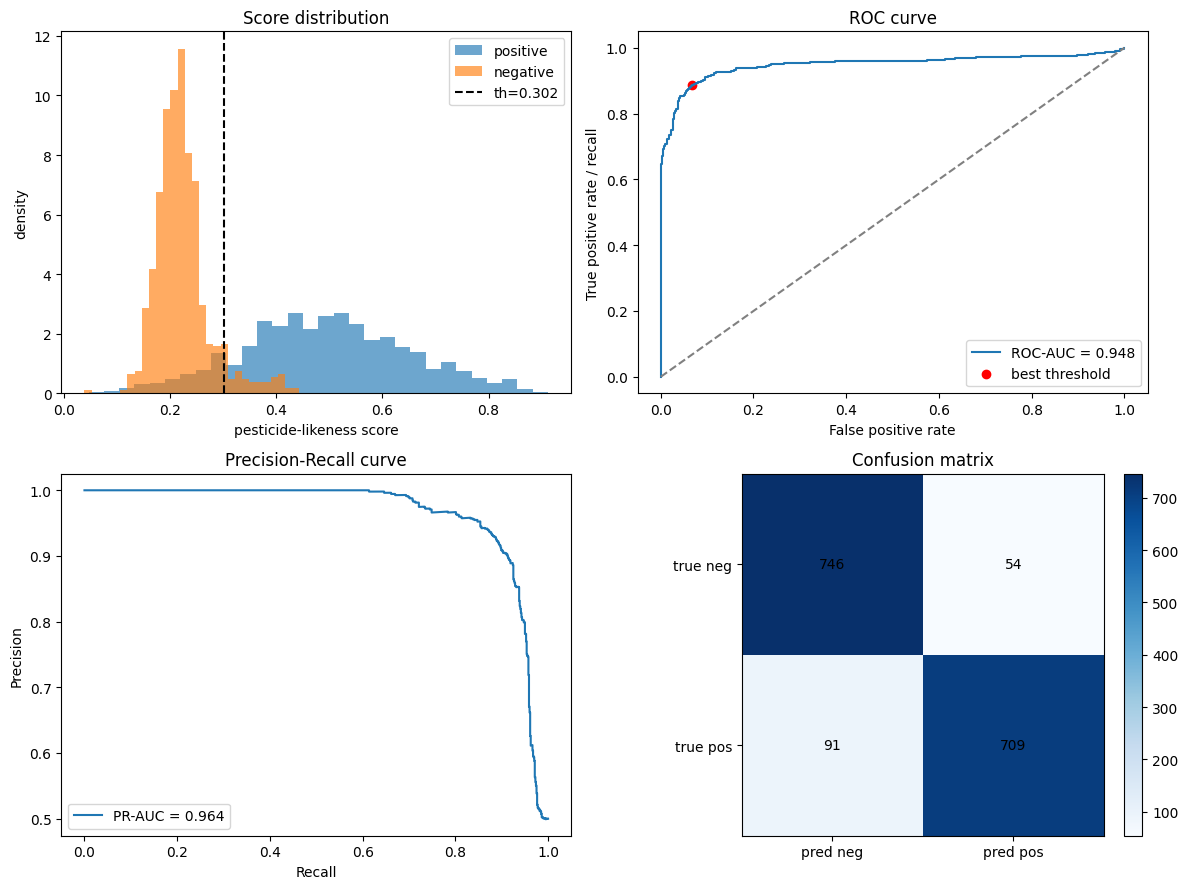

[시간] Task 3 - score 평가 지표 전체 확인: 셀 2.51초 / 누적 17.64초


In [11]:
# Task 3 - score 평가 지표 전체 확인
cell_start = time.perf_counter()

# 1. positive와 negative의 최종 score를 계산한다.
eval_positive_scores = test_positive['smiles'].map(pesticide_likeness_score).dropna().to_numpy()
eval_negative_scores = negative_eval['smiles'].map(pesticide_likeness_score).dropna().to_numpy()

# y_true는 정답이다. positive는 1, negative는 0으로 둔다.
y_true = np.array([1] * len(eval_positive_scores) + [0] * len(eval_negative_scores))
y_score = np.concatenate([eval_positive_scores, eval_negative_scores])

# 2. threshold가 필요 없는 ranking 지표
# ROC-AUC: positive가 negative보다 높은 score를 받을수록 1에 가까워진다.
fpr, tpr, roc_thresholds = roc_curve(y_true, y_score)
score_auc = roc_auc_score(y_true, y_score)

# PR-AUC: positive로 예측한 것들 중 실제 positive 비율과, positive를 얼마나 잘 잡는지를 본다.
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_true, y_score)
pr_auc = average_precision_score(y_true, y_score)

# KS statistic: ROC curve에서 TPR-FPR 차이가 가장 큰 지점이다.
youden_j_values = tpr - fpr
best_threshold_idx = int(np.argmax(youden_j_values))
best_threshold = roc_thresholds[best_threshold_idx]
ks_statistic = youden_j_values[best_threshold_idx]

# 3. threshold 기반 지표
# threshold 이상이면 positive(1), 미만이면 negative(0)로 분류한다.
y_pred = (y_score >= best_threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
specificity = tn / (tn + fp) if (tn + fp) else 0.0
false_positive_rate = fp / (fp + tn) if (fp + tn) else 0.0
false_negative_rate = fn / (fn + tp) if (fn + tp) else 0.0

classification_metrics = {
    'threshold': best_threshold,
    'roc_auc': score_auc,
    'pr_auc_average_precision': pr_auc,
    'ks_statistic_youden_j': ks_statistic,
    'accuracy': accuracy_score(y_true, y_pred),
    'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
    'precision': precision_score(y_true, y_pred, zero_division=0),
    'recall_sensitivity': recall_score(y_true, y_pred, zero_division=0),
    'specificity': specificity,
    'f1_score': f1_score(y_true, y_pred, zero_division=0),
    'mcc': matthews_corrcoef(y_true, y_pred),
    'false_positive_rate': false_positive_rate,
    'false_negative_rate': false_negative_rate,
    'tp': tp,
    'fp': fp,
    'tn': tn,
    'fn': fn,
}

# 4. score 분포 요약
score_summary = pd.DataFrame({
    'group': ['positive_test', 'negative'],
    'n': [len(eval_positive_scores), len(eval_negative_scores)],
    'mean_score': [eval_positive_scores.mean(), eval_negative_scores.mean()],
    'median_score': [np.median(eval_positive_scores), np.median(eval_negative_scores)],
    'std_score': [eval_positive_scores.std(), eval_negative_scores.std()],
    'min_score': [eval_positive_scores.min(), eval_negative_scores.min()],
    'max_score': [eval_positive_scores.max(), eval_negative_scores.max()],
})

metrics_df = pd.DataFrame([classification_metrics]).T.reset_index()
metrics_df.columns = ['metric', 'value']

display(Markdown('### Score distribution summary'))
display(score_summary.round(4))

display(Markdown('### Classification metrics at best threshold'))
display(metrics_df.round(4))

# 5. 시각화: histogram, ROC curve, PR curve, confusion matrix
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

axes[0, 0].hist(eval_positive_scores, bins=30, alpha=0.65, label='positive', density=True)
axes[0, 0].hist(eval_negative_scores, bins=30, alpha=0.65, label='negative', density=True)
axes[0, 0].axvline(best_threshold, color='black', linestyle='--', label=f'th={best_threshold:.3f}')
axes[0, 0].set_xlabel('pesticide-likeness score')
axes[0, 0].set_ylabel('density')
axes[0, 0].set_title('Score distribution')
axes[0, 0].legend()

axes[0, 1].plot(fpr, tpr, label=f'ROC-AUC = {score_auc:.3f}')
axes[0, 1].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[0, 1].scatter(fpr[best_threshold_idx], tpr[best_threshold_idx], color='red', label='best threshold')
axes[0, 1].set_xlabel('False positive rate')
axes[0, 1].set_ylabel('True positive rate / recall')
axes[0, 1].set_title('ROC curve')
axes[0, 1].legend()

axes[1, 0].plot(recall_curve, precision_curve, label=f'PR-AUC = {pr_auc:.3f}')
axes[1, 0].set_xlabel('Recall')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].set_title('Precision-Recall curve')
axes[1, 0].legend()

cm = np.array([[tn, fp], [fn, tp]])
im = axes[1, 1].imshow(cm, cmap='Blues')
axes[1, 1].set_xticks([0, 1])
axes[1, 1].set_yticks([0, 1])
axes[1, 1].set_xticklabels(['pred neg', 'pred pos'])
axes[1, 1].set_yticklabels(['true neg', 'true pos'])
axes[1, 1].set_title('Confusion matrix')
for row in range(2):
    for col in range(2):
        axes[1, 1].text(col, row, cm[row, col], ha='center', va='center', color='black')
fig.colorbar(im, ax=axes[1, 1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig('score_evaluation_agrochemical.png', dpi=200)
plt.show()

show_runtime('Task 3 - score 평가 지표 전체 확인', cell_start)


**Score 평가 해석**

Score 평가는 하나의 지표만 보지 않고 여러 관점에서 확인했다. Histogram은 positive와 negative 점수 분포가 얼마나 떨어져 있는지 보여주고, ROC-AUC는 threshold를 바꿔도 positive가 negative보다 높은 점수를 받는지를 본다. PR-AUC는 positive로 예측한 후보의 정밀도와 positive를 얼마나 많이 회수했는지를 함께 본다.

Threshold가 필요한 지표는 ROC curve에서 `TPR - FPR`이 가장 큰 Youden J 지점을 기준으로 계산했다. 이 threshold에서 accuracy, precision, recall, specificity, F1, balanced accuracy, MCC, confusion matrix를 함께 확인한다.


## [상세 설명] Task 3

히스토그램은 score 자체가 두 집단을 얼마나 분리하는지 직관적으로 보여준다. Positive 막대가 오른쪽, negative 막대가 왼쪽에 몰리면 score가 positive-likeness를 잘 반영한다는 뜻이다.

ROC-AUC는 threshold를 하나로 고정하지 않고 가능한 모든 threshold에서 성능을 본다. AUC가 1.0에 가까울수록 positive가 negative보다 일관되게 높은 score를 받는다는 뜻이고, 0.5면 무작위 수준이다. PR-AUC는 precision과 recall의 관계를 보는 지표라서, 실제 선별 작업에서 "positive라고 고른 후보가 얼마나 믿을 만한가"를 볼 때 유용하다.

Threshold 기반 지표는 score를 실제 분류로 바꿨을 때의 성능이다. Accuracy는 전체 중 맞춘 비율이고, precision은 positive라고 예측한 것 중 진짜 positive 비율이다. Recall은 실제 positive 중 찾아낸 비율이고, specificity는 실제 negative 중 negative로 잘 거른 비율이다. F1은 precision과 recall의 조화평균이고, balanced accuracy는 positive/negative 양쪽을 균형 있게 본다. MCC는 confusion matrix 전체를 반영하는 지표로, 클래스 균형이 달라져도 비교적 안정적으로 쓸 수 있다.


---
# Task 4. 알고리즘 흐름 설명 - Mermaid Diagram

```mermaid
flowchart TD
    A[CSV 파일 선택] --> B[컬럼 이름 표준화]
    B --> C[SMILES를 RDKit Mol로 변환]
    C --> D[Positive train/test 분리]
    D --> E[Morgan fingerprint 생성]
    E --> F[Negative 후보와 positive train의 최대 Tanimoto 계산]
    F --> G{max similarity <= 0.30?}
    G -- Yes --> H[Negative 집합 저장]
    G -- No --> I[Negative 후보 제외]
    D --> J[Positive 물성 5~95 percent 범위 계산]
    D --> K[Murcko scaffold 추출]
    K --> L[상위 scaffold를 SMARTS 패턴으로 변환]
    J --> M[property_score]
    L --> N[smarts_score]
    E --> O[similarity_score]
    M --> P[최종 score = 0.30 property + 0.25 SMARTS + 0.45 similarity]
    N --> P
    O --> P
    H --> Q[Positive vs Negative score 평가]
    S --> Q
    Q --> R[Histogram, ROC, AUC]
```

```mermaid
flowchart TD
    A[가산 B 시작 SMILES] --> B[현재 분자 score 계산]
    B --> C[원자 치환 및 원자 추가로 이웃 분자 생성]
    C --> D[유효한 SMILES만 sanitize]
    D --> E[각 이웃의 score 계산]
    E --> F{최고 이웃 score > 현재 score?}
    F -- Yes --> G[최고 이웃으로 이동]
    F -- No --> H[탐욕 탐색 종료]
    G --> C
```

```mermaid
flowchart TD
    A[가산 C 대량 파일 목록] --> B[MPI rank별 파일 분배]
    B --> C[각 worker가 SMILES 읽기]
    C --> D[Hash set 또는 score 함수로 계산]
    D --> E[worker 결과를 rank 0으로 gather/reduce]
    E --> F[총 개수, 시간, 결과 CSV/log 저장]
```


## [상세 설명] Task 4

첫 번째 mermaid 다이어그램은 이 노트북의 핵심 파이프라인이다. 데이터 로드에서 시작해 negative 생성, score 설계, 평가까지 이어진다. Task 1은 fingerprint와 Tanimoto로 negative를 만드는 부분이고, Task 2는 property/SMARTS/similarity score를 만드는 부분이며, Task 3은 histogram과 ROC/AUC로 검증하는 부분이다.

두 번째 다이어그램은 `w9-1_molecule_greedy.ipynb`와 `w10-1_molecule_dp.ipynb`에서 배운 구조 생성 흐름을 이 과제 score에 연결한 것이다. Greedy는 매 단계에서 현재보다 좋은 이웃을 선택하므로 빠르지만, 더 멀리 가야 나오는 더 좋은 구조를 놓칠 수 있다. DP/beam search는 후보를 더 넓게 유지해 이 한계를 줄인다.

세 번째 다이어그램은 MPI 계산 흐름이다. 수업자료와 `mpi_compare_search.py`, `search_candidates_mpi_0513.py`는 rank별로 파일이나 후보를 나눠 계산하고 rank 0에서 결과를 모으는 master-worker 또는 round-robin 구조를 사용했다.


---
# (가산 A) 다른 화학 제품군 score 함수 (+10)

`CONFIG['alt_positive_file']`에 지정한 `PubChem_HumanDrugs.csv`를 positive로 두고 같은 절차를 적용한다. 함수 구조는 pesticide score와 같고, 파일명만 바꾸면 다른 제품군 score를 만들 수 있다.


In [12]:
# 가산 A - HumanDrugs score를 같은 함수 구조로 생성 및 평가
cell_start = time.perf_counter()

def build_category_model(positive_file, negative_candidate_file, label, random_state=7):
    pos = ensure_descriptors(load_pubchem_csv(positive_file))
    cand = load_pubchem_csv(negative_candidate_file)
    train = pos.sample(min(1000, len(pos)), random_state=random_state)
    test_pool = pos.drop(train.index)
    test = test_pool.sample(min(600, len(test_pool)), random_state=random_state + 1)
    ref_fps = [make_fingerprint(mol) for mol in train['mol']]
    ranges = {col: tuple(train[col].quantile([0.05, 0.95])) for col in PROPERTY_COLUMNS}
    patterns = mine_scaffold_smarts(train, top_n=25)

    neg_rows = []
    for _, row in cand.sample(frac=1, random_state=random_state + 2).iterrows():
        mx = max_tanimoto_to_refs(row['mol'], ref_fps)
        if mx <= CONFIG['negative_similarity_threshold']:
            neg_rows.append({'smiles': row['smiles'], 'mol': row['mol'], 'max_similarity_to_positive': mx})
        if len(neg_rows) >= len(test):
            break
    neg = pd.DataFrame(neg_rows)

    def category_score(smiles):
        mol = Chem.MolFromSmiles(str(smiles))
        if mol is None:
            return np.nan
        prop = property_score(mol, ranges)
        match_score = smarts_score(mol, patterns)
        sim = max_tanimoto_to_refs(mol, ref_fps)
        return 0.30 * prop + 0.25 * match_score + 0.45 * sim

    pos_scores = test['smiles'].map(category_score).dropna().to_numpy()
    neg_scores = neg['smiles'].map(category_score).dropna().to_numpy()
    y = np.array([1] * len(pos_scores) + [0] * len(neg_scores))
    s = np.concatenate([pos_scores, neg_scores])
    model_auc = roc_auc_score(y, s)
    print(f'[{label}] positive_n:', len(pos_scores))
    print(f'[{label}] negative_n:', len(neg_scores))
    print(f'[{label}] positive_mean_score:', round(pos_scores.mean(), 3))
    print(f'[{label}] negative_mean_score:', round(neg_scores.mean(), 3))
    print(f'[{label}] AUC:', round(model_auc, 3))
    return category_score, model_auc

human_drug_score, human_drug_auc = build_category_model(
    CONFIG['alt_positive_file'],
    CONFIG['positive_file'],
    label='HumanDrugs',
)

show_runtime('가산 A - HumanDrugs score를 같은 함수 구조로 생성 및 평가', cell_start)

[HumanDrugs] positive_n: 600
[HumanDrugs] negative_n: 600
[HumanDrugs] positive_mean_score: 0.481
[HumanDrugs] negative_mean_score: 0.27
[HumanDrugs] AUC: 0.86
[시간] 가산 A - HumanDrugs score를 같은 함수 구조로 생성 및 평가: 셀 4.93초 / 누적 22.58초


## [상세 설명] 가산 A

가산 A의 핵심은 pesticide가 아닌 다른 화학 제품군에도 같은 score 설계 절차를 적용하는 것이다. 여기서는 폴더 안에 이미 있는 `PubChem_HumanDrugs.csv`를 사용했다. `build_category_model` 함수는 positive 파일명과 negative 후보 파일명을 인자로 받으므로, cosmetic, food additive, fragrance 같은 CSV가 추가되면 같은 함수에 파일명만 넘기면 된다.


---
# (가산 B) Score 기반 구조 생성 (+10)

본인 score를 reward로 사용해 탐욕 알고리즘으로 구조를 개선한다. 수업자료 `w9-1_molecule_greedy.ipynb`의 원자 치환/추가 방식과 `w10-1_molecule_dp.ipynb`의 후보 확장 개념을 단순화해 적용했다.


In [13]:
# 가산 B - pesticide_likeness_score를 reward로 사용하는 간단한 greedy 구조 생성
cell_start = time.perf_counter()

def generate_neighbors(smiles, atom_nums=(6, 7, 8, 9, 17), max_neighbors=300):
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        return []
    results = set()
    for i in range(mol.GetNumAtoms()):
        for atom_num in atom_nums:
            rw = Chem.RWMol(mol)
            rw.GetAtomWithIdx(i).SetAtomicNum(atom_num)
            try:
                Chem.SanitizeMol(rw)
                results.add(Chem.MolToSmiles(rw))
            except Exception:
                pass
            if len(results) >= max_neighbors:
                return list(results)
    for i in range(min(mol.GetNumAtoms(), 12)):
        for atom_num in (6, 7, 8):
            rw = Chem.RWMol(mol)
            new_idx = rw.AddAtom(Chem.Atom(atom_num))
            rw.AddBond(i, new_idx, Chem.BondType.SINGLE)
            try:
                Chem.SanitizeMol(rw)
                results.add(Chem.MolToSmiles(rw))
            except Exception:
                pass
            if len(results) >= max_neighbors:
                return list(results)
    return list(results)

def greedy_optimize(start_smiles, steps=5):
    current = Chem.MolToSmiles(Chem.MolFromSmiles(start_smiles))
    history = [{'step': 0, 'smiles': current, 'score': pesticide_likeness_score(current)}]
    visited = {current}
    for step in range(1, steps + 1):
        candidates = [s for s in generate_neighbors(current) if s not in visited]
        scored = [(pesticide_likeness_score(s), s) for s in candidates]
        scored = [(score, smi) for score, smi in scored if not np.isnan(score)]
        if not scored:
            break
        best_score, best_smiles = max(scored, key=lambda x: x[0])
        visited.add(best_smiles)
        if best_score <= history[-1]['score']:
            break
        current = best_smiles
        history.append({'step': step, 'smiles': current, 'score': best_score})
    return pd.DataFrame(history)

start_smiles = test_positive.iloc[0]['smiles']
greedy_history = greedy_optimize(start_smiles, steps=5)
greedy_history.to_csv('generated_greedy_pesticide_score.csv', index=False)
greedy_history

show_runtime('가산 B - pesticide_likeness_score를 reward로 사용하는 간단한 greedy 구조 ', cell_start)

[시간] 가산 B - pesticide_likeness_score를 reward로 사용하는 간단한 greedy 구조 : 셀 0.26초 / 누적 22.85초


## [상세 설명] 가산 B

구조 생성은 가능한 모든 분자를 만드는 문제가 아니라, 현재 분자 주변의 작은 변형을 만들고 score가 올라가는 방향으로 이동하는 최적화 문제로 다루었다. `generate_neighbors`는 원자 치환과 원자 하나 추가를 사용한다. 이 방식은 수업자료의 greedy 예제와 같다. 다만 원자 종류와 후보 수를 제한하지 않으면 가능한 구조 수가 급격히 늘어나므로 `max_neighbors`로 탐색 공간을 제한했다.

`greedy_optimize`는 매 단계에서 후보 이웃을 만들고 `pesticide_likeness_score`가 가장 높은 후보를 고른다. 새 후보의 score가 현재보다 높지 않으면 멈춘다. Greedy는 빠르고 설명하기 쉽지만, 한 단계 손해를 본 뒤 더 좋아지는 경로는 찾지 못할 수 있다.


---
# (가산 C) 계산 자원과 계산 시간 (+10)

수업 코드에는 MPI로 ZINC 파일을 나눠 처리한 script와 log가 있다. `search_resultsA.txt`에는 55개 일치 검색에서 linear 17.55초, binary 2.53초, hash 2.17초가 기록되어 있고, `search_results.txt`에는 더 큰 실행에서 linear 13276.82초, binary 1625.38초, hash 1378.85초가 기록되어 있다. 본 노트북에서는 재현 가능한 작은 샘플로 list membership과 set membership 시간을 비교한다.


In [14]:
# 가산 C - 전체 코드 실행 시간 요약과 로컬 탐색 시간 비교
cell_start = time.perf_counter()

# 위에서 실행된 모든 주요 코드 셀의 실행 시간을 표로 모은다.
runtime_df = pd.DataFrame(CELL_TIMES)
display(runtime_df.round(3))
print('현재까지 누적 실행 시간:', round(time.perf_counter() - NOTEBOOK_START, 2), '초')

# 아래는 수업 때 했던 list membership과 set/hash membership 비교이다.
# 같은 정답을 찾더라도 set을 쓰면 membership 확인이 평균적으로 매우 빠르다.
sample_positive_smiles = positive_df['smiles'].head(2000).tolist()
sample_query_smiles = pd.concat([
    positive_df['smiles'].head(200),
    negative_candidate_df['smiles'].head(2000),
]).dropna().astype(str).tolist()

start = time.perf_counter()
list_hits = sum(1 for smi in sample_query_smiles if smi in sample_positive_smiles)
list_time = time.perf_counter() - start

positive_set = set(sample_positive_smiles)
start = time.perf_counter()
set_hits = sum(1 for smi in sample_query_smiles if smi in positive_set)
set_time = time.perf_counter() - start

speedup = list_time / set_time if set_time > 0 else np.inf
timing_df = pd.DataFrame({
    'method': ['list membership', 'set/hash membership'],
    'hits': [list_hits, set_hits],
    'seconds': [list_time, set_time],
})
display(timing_df)
print('local speedup(list/set):', round(speedup, 2))
print('search_resultsA.txt: linear 17.55s, binary 2.53s, hash 2.17s, hits 55')
print('search_results.txt : linear 13276.82s, binary 1625.38s, hash 1378.85s, hits 78')

show_runtime('가산 C - 전체 코드 실행 시간 요약과 로컬 탐색 시간 비교', cell_start)


,step,cell_seconds,cumulative_seconds
0,공통 import,1.192,1.192
1,Task 1-1. 설정값 정리,0.000,1.200
2,Task 1-2. 파일 읽기와 Tanimoto 계산 함수,0.001,1.208
3,Task 1-3. positive와 ZINC 후보 데이터 읽기,0.539,1.752
4,Task 1-4. ZINC 후보 중 negative 선택,0.400,2.158
5,Task 1-5. Tanimoto 유사도 0.1 단위별 실제 구조 예시 보기,1.732,3.897
6,Task 2-1. descriptor 컬럼 준비,0.259,4.165
7,Task 2-2. 물성 기반 property_score 함수,0.000,4.173
8,Task 2-3. Murcko scaffold 기반 SMARTS 점수,0.159,4.339
9,Task 2-4. score 가중치와 물성 범위 최적화,10.764,15.114


현재까지 누적 실행 시간: 22.86 초


,method,hits,seconds
0,list membership,200,0.037236
1,set/hash membership,200,0.000274


local speedup(list/set): 136.05
search_resultsA.txt: linear 17.55s, binary 2.53s, hash 2.17s, hits 55
search_results.txt : linear 13276.82s, binary 1625.38s, hash 1378.85s, hits 78
[시간] 가산 C - 전체 코드 실행 시간 요약과 로컬 탐색 시간 비교: 셀 0.05초 / 누적 22.91초


## [상세 설명] 가산 C

수업자료의 검색 비교는 같은 정답 개수를 찾더라도 자료구조와 병렬화에 따라 시간이 크게 달라진다는 점을 보여준다. Linear search는 query 하나마다 전체 리스트를 순서대로 확인하므로 대략 `O(m*n)`에 가깝다. Binary search는 정렬된 리스트에서 `O(log n)`으로 찾지만, 정렬 비용과 문자열 비교 비용이 있다. Hash search는 set을 만든 뒤 평균적으로 `O(1)` membership을 수행하므로 반복 검색에 유리하다.

MPI script의 핵심은 파일 단위 또는 후보 단위로 작업을 나누는 것이다. 각 rank가 서로 다른 파일을 처리하고, rank 0이 결과를 모으면 전체 wall time을 줄일 수 있다. 이 노트북의 score 함수도 분자별 계산이 독립적이므로 MPI에 잘 맞는다.


---
# 추가 반영 내용 정리

- `W1-2AL.ipynb`, `w2-2_download_zinc.ipynb`: ZINC txt/uri 다운로드와 tab-separated ZINC 파일 구조를 확인하는 내용이 있어, 이 노트북에서는 현재 폴더의 PubChem CSV와 `zinc_db`에서 생성한 negative CSV를 사용하도록 했다.
- `w3-1_divide_and_conquer-student.ipynb`, `w4-1_sorting-student.ipynb`: 대량 데이터를 한 번에 다루기보다 필요한 컬럼만 읽고, Dask/MPI로 나눠 계산하는 관점을 가산 C에 연결했다.
- `w7-2_graph_algorithm.ipynb`: RDKit 분자는 원자 node와 결합 edge로 이루어진 graph이며, adjacency/distance matrix로 구조 descriptor를 만들 수 있다는 내용을 SMARTS/scaffold 설명에 연결했다.
- `w9-1_molecule_greedy.ipynb`, `w9-1_molecule_greedy_additional_description.ipynb`: QED와 logP 기반 score, 원자 치환/추가 이웃 생성, greedy loop를 가산 B의 구조 생성 코드에 반영했다.
- `w10-1_molecule_dp.ipynb`: greedy의 한계와 DP/캐싱/beam 개념을 구조 생성 상세 설명에 반영했다.
- `w10-2_agrochemical_score.ipynb`: agrochemical 물성 범위와 QED 스타일 가중 결합 아이디어를 Task 2 score 함수에 반영했다.
- `w11-1_smarts_pesticide.ipynb`: Murcko scaffold와 SMARTS 매칭을 Task 2에 반영했다.
- `w11-2_fingerprint_tanimoto.ipynb`: Morgan fingerprint와 Tanimoto 유사도, 최대 유사도 계산을 Task 1과 Task 2에 반영했다.

별도의 독립적인 대화 기록 파일은 작업 대상 폴더에서 명확히 식별되지 않았다. 따라서 실제 파일로 존재하는 노트북, Python script, txt/csv/log성 결과 파일의 내용만 반영했다.
